In [14]:
# 1. Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Імпорт модулів scikit-learn для ML
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Налаштування для візуалізації
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Завантаження набору даних Titanic
titanic_df = sns.load_dataset('titanic')
print("Набір даних успішно завантажено.")

Набір даних успішно завантажено.


In [15]:
# Виведення перших 10 рядків
print("Перші 10 рядків даних:")
print(titanic_df.head(10))

# Базова статистика
print("\nБазова статистика (describe):")
print(titanic_df.describe())

# Інформація про типи даних та пропущені значення
print("\nІнформація про дані (info):")
titanic_df.info()

# Точна кількість пропущених значень
print("\nКількість пропущених значень по стовпцях:")
print(titanic_df.isnull().sum())

Перші 10 рядків даних:
   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False 

In [17]:
# 1. Створюємо копію
df = titanic_df.copy()

# 2. Обробка пропущених значень
# Заповнюємо 'Age' середнім значенням
df['age'].fillna(df['age'].mean(), inplace=True)
# Заповнюємо 'Embarked' модою (найбільш поширеним значенням)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# 3. Видаляємо стовпці з великою кількістю пропусків ('deck') або непотрібні
# Створюємо список стовпців для видалення і перевіряємо їх наявність
columns_to_drop = ['deck', 'embarked_town']
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_cols_to_drop:
    df.drop(existing_cols_to_drop, axis=1, inplace=True)
    print(f"Видалено стовпці: {existing_cols_to_drop}")
else:
    print("Стовпці 'deck' та 'embarked_town' не знайдено або вже видалено.")

# 4. Створення нових ознак
# Створюємо 'FamilySize'
df['family_size'] = df['sibsp'] + df['parch']
# Створюємо бінарну ознаку 'alone'
df['alone'] = df['family_size'].apply(lambda x: 1 if x == 0 else 0)

# 5. Кодування категоріальних змінних
# One-Hot Encoding для 'sex' та 'embarked'. drop_first=True
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

# 6. Видалення зайвих стовпців (оновлений список)
columns_to_drop_final = ['passenger_id', 'name', 'ticket', 'class', 'who', 'adult_male', 'alive', 'sibsp', 'parch']
existing_cols_to_drop_final = [col for col in columns_to_drop_final if col in df.columns]

if existing_cols_to_drop_final:
    df.drop(existing_cols_to_drop_final, axis=1, inplace=True)
    print(f"Видалено зайві стовпці: {existing_cols_to_drop_final}")

print("\nДані після попередньої обробки:")
print(df.head())
print("\nПеревірка на наявність пропусків після обробки:")
print(df.isnull().sum())

Видалено стовпці: ['deck']
Видалено зайві стовпці: ['class', 'who', 'adult_male', 'alive', 'sibsp', 'parch']

Дані після попередньої обробки:
   survived  pclass   age     fare  embark_town  alone  family_size  sex_male  \
0         0       3  22.0   7.2500  Southampton      0            1      True   
1         1       1  38.0  71.2833    Cherbourg      0            1     False   
2         1       3  26.0   7.9250  Southampton      1            0     False   
3         1       1  35.0  53.1000  Southampton      0            1     False   
4         0       3  35.0   8.0500  Southampton      1            0      True   

   embarked_Q  embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  

Перевірка на наявність пропусків після обробки:
survived       0
pclass         0
age            0
fare           0
embark_town    2
alone          0
family_size    0
sex_male       0
embarked_Q     0
e

In [20]:
# 1. Визначення X (ознаки) та y (цільова змінна)
X = df.drop('survived', axis=1) # Ознаки
y = df['survived'] # Цільова змінна

# 2. Очищення від нечислових стовпців перед масштабуванням/ML
# Цей крок гарантує, що у X залишаться ТІЛЬКИ числові дані (float64, int64, uint8),
# які потрібні для StandardScaler та моделей.
X = X.select_dtypes(include=['float64', 'int64', 'uint8']).copy()


# 3. Розділення на тренувальну та тестову вибірки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Масштабування даних (StandardScaler)
# Це потрібно для Логістичної регресії
scaler = StandardScaler()
# Навчаємо scaler тільки на тренувальних даних!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Розмір тренувальної вибірки (X): {X_train.shape}")
print(f"Розмір тестової вибірки (X): {X_test.shape}")

Розмір тренувальної вибірки (X): (712, 5)
Розмір тестової вибірки (X): (179, 5)


In [21]:
results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Функція для тренування, передбачення та оцінки моделі."""
    print(f"--- Оцінка моделі: {name} ---")
    
    # Тренування
    model.fit(X_train, y_train)
    
    # Передбачення
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Ймовірності для ROC-AUC

    # Оцінка метрик
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    # Зберігаємо результати
    results[name] = {
        'model': model, 
        'y_pred': y_pred, 
        'y_prob': y_prob,
        'accuracy': accuracy, 
        'precision': precision, 
        'recall': recall, 
        'f1': f1
    }
    return results

# 1. Логістична регресія (використовуємо масштабовані дані)
log_reg = LogisticRegression(random_state=42)
evaluate_model('Логістична регресія', log_reg, X_train_scaled, y_train, X_test_scaled, y_test)

# 2. Дерево рішень (використовуємо немасштабовані дані)
tree_clf = DecisionTreeClassifier(random_state=42)
evaluate_model('Дерево рішень', tree_clf, X_train, y_train, X_test, y_test)

# 3. Випадковий ліс (використовуємо немасштабовані дані)
rf_clf = RandomForestClassifier(random_state=42)
evaluate_model('Випадковий ліс', rf_clf, X_train, y_train, X_test, y_test)

--- Оцінка моделі: Логістична регресія ---
Accuracy: 0.7654
Precision: 0.8077
Recall: 0.5676
F1-score: 0.6667
--- Оцінка моделі: Дерево рішень ---
Accuracy: 0.6648
Precision: 0.6029
Recall: 0.5541
F1-score: 0.5775
--- Оцінка моделі: Випадковий ліс ---
Accuracy: 0.7151
Precision: 0.6825
Recall: 0.5811
F1-score: 0.6277


{'Логістична регресія': {'model': LogisticRegression(random_state=42),
  'y_pred': array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
         0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
         0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
         0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
         1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
         0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
         0, 0, 0]),
  'y_prob': array([0.30208848, 0.35329698, 0.2635648 , 0.73264718, 0.48090018,
         0.64518437, 0.2104635 , 0.39890702, 0.28758757, 0.73604316,
         0.71171286, 0.14754047, 0.19811153, 0.20856412, 0.32194624,
         0.81434293, 0.67913504, 0.2105225 , 0.3840971 , 0.46043102,
         0.24

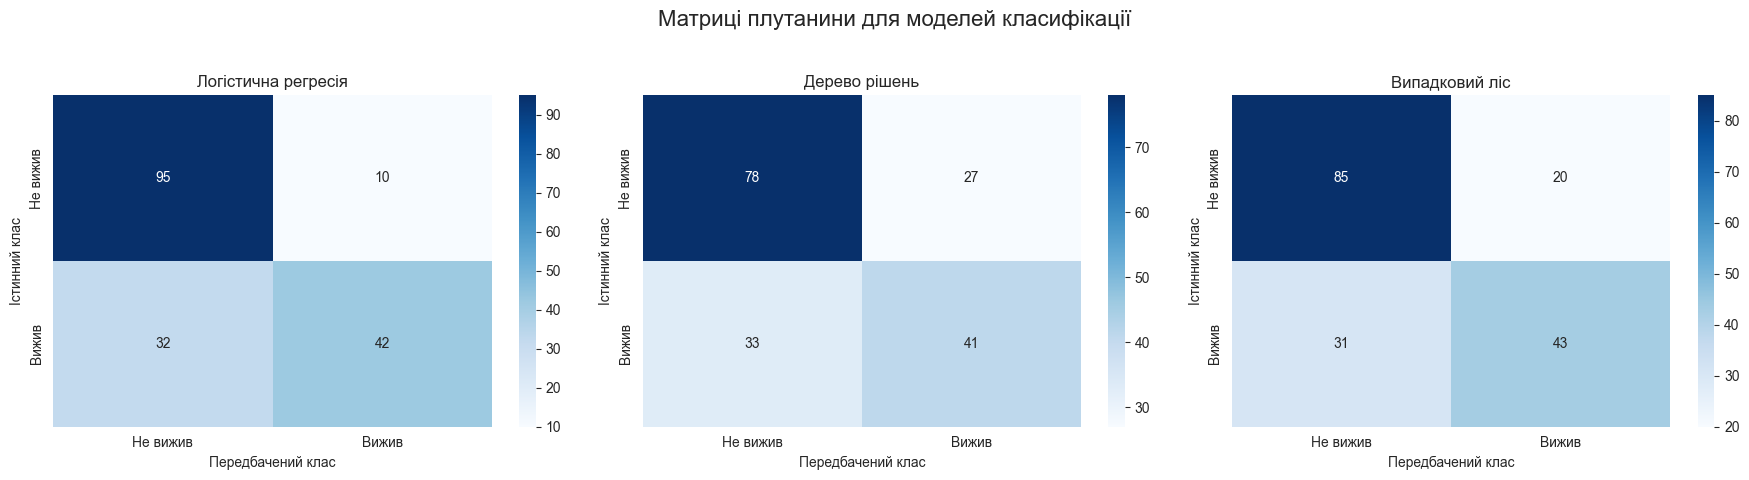

In [22]:
# 6. Візуалізація Матриць плутанини
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Матриці плутанини для моделей класифікації', fontsize=16)

for i, (name, res) in enumerate(results.items()):
    # Розрахунок матриці плутанини
    cm = confusion_matrix(y_test, res['y_pred'])
    
    # Побудова теплової карти
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Не вижив', 'Вижив'],
                yticklabels=['Не вижив', 'Вижив'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Передбачений клас')
    axes[i].set_ylabel('Істинний клас')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

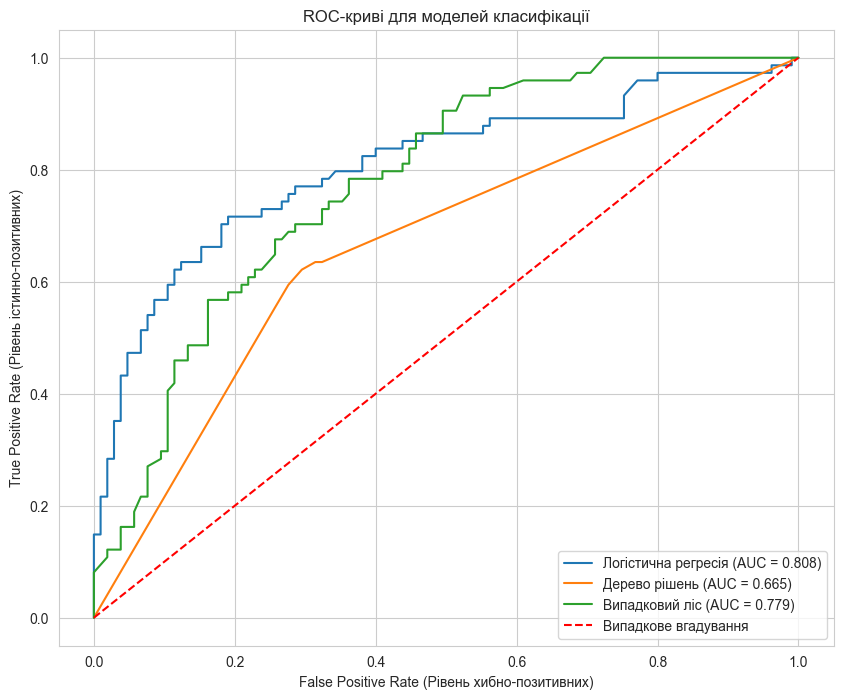

In [23]:
# 7. Візуалізація ROC-кривих та AUC
plt.figure(figsize=(10, 8))

# Додаємо ROC для кожної моделі
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# Базова лінія (випадкове вгадування)
plt.plot([0, 1], [0, 1], 'r--', label='Випадкове вгадування')

# Налаштування графіку
plt.xlabel('False Positive Rate (Рівень хибно-позитивних)')
plt.ylabel('True Positive Rate (Рівень істинно-позитивних)')
plt.title('ROC-криві для моделей класифікації')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [24]:
# 8. Крос-валідація (Логістична регресія та Дерево рішень)

# Створюємо пайплайн для Логістичної регресії (Включаючи масштабування)
pipe_log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

# Створюємо пайплайн для Дерева рішень (без масштабування)
pipe_tree = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])

# Виконуємо крос-валідацію (cv=5) на повному наборі даних X, y
cv_scores_log = cross_val_score(pipe_log_reg, X, y, cv=5, scoring='accuracy') 
cv_scores_tree = cross_val_score(pipe_tree, X, y, cv=5, scoring='accuracy')

print("--- Крос-валідація (Accuracy) ---")
print(f"Логістична регресія (середнє): {cv_scores_log.mean():.4f} (std: {cv_scores_log.std():.4f})")
print(f"Дерево рішень (середнє): {cv_scores_tree.mean():.4f} (std: {cv_scores_tree.std():.4f})")

--- Крос-валідація (Accuracy) ---
Логістична регресія (середнє): 0.7206 (std: 0.0443)
Дерево рішень (середнє): 0.6521 (std: 0.0257)


In [25]:
# 9. Оптимізація гіперпараметрів для Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Ініціалізація GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Навчання на тренувальних даних
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("\n--- Оптимізація гіперпараметрів (Random Forest) ---")
print(f"Найкращі параметри: {grid_search.best_params_}")
print(f"Найкраща оцінка крос-валідації (Accuracy): {grid_search.best_score_:.4f}")

# Оцінка найкращої моделі на тестовій вибірці
evaluate_model('Випадковий ліс (Оптимізований)', best_rf, X_train, y_train, X_test, y_test)


--- Оптимізація гіперпараметрів (Random Forest) ---
Найкращі параметри: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Найкраща оцінка крос-валідації (Accuracy): 0.7246
--- Оцінка моделі: Випадковий ліс (Оптимізований) ---
Accuracy: 0.7486
Precision: 0.7959
Recall: 0.5270
F1-score: 0.6341


{'Логістична регресія': {'model': LogisticRegression(random_state=42),
  'y_pred': array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
         0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
         0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
         0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
         1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
         0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
         0, 0, 0]),
  'y_prob': array([0.30208848, 0.35329698, 0.2635648 , 0.73264718, 0.48090018,
         0.64518437, 0.2104635 , 0.39890702, 0.28758757, 0.73604316,
         0.71171286, 0.14754047, 0.19811153, 0.20856412, 0.32194624,
         0.81434293, 0.67913504, 0.2105225 , 0.3840971 , 0.46043102,
         0.24


--- Важливість ознак (Random Forest) ---
fare           0.376623
age            0.235532
pclass         0.220183
family_size    0.133800
alone          0.033862
dtype: float64


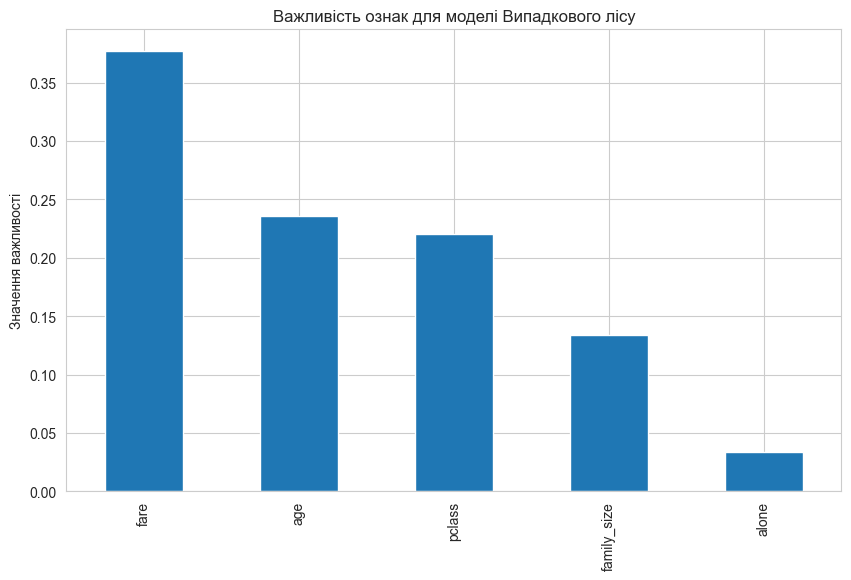

In [ ]:
# 10. Аналіз важливості ознак (Featurecopy lab4.ipynb lab_4/ Importance)
# Використовуємо найкращу навчену модель (best_rf)
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
sorted_importances = feature_importances.sort_values(ascending=False)git add .

print("\n--- Важливість ознак (Random Forest) ---")
print(sorted_importances)

# Візуалізація
plt.figure(figsize=(10, 6))
sorted_importances.plot(kind='bar')
plt.title('Важливість ознак для моделі Випадкового лісу')
plt.ylabel('Значення важливості')
plt.show()